<a href="https://colab.research.google.com/github/Tiyinolalekan/Deep_Learning_Image_Classifier/blob/main/Image_Classifier_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Creating a simple image classifier usingg PyTorch and CIFAR-10


In [7]:
import torch #Main PyTorch library
import torch.nn as nn # Neural network compnents
import torch.optim as optim #Optimisers for training
import torchvision #Computer-vision datasets/tools
import torchvision.transforms as transforms #Preparing images
import matplotlib.pyplot as plt #to visualise images

"""
CHECKING IMPORTS AND STUFF
print(torch.__version__)
print(torch.cuda.is_available()) #Checking if a GPU is available

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') ##Resulting to use CPU if GPU isnt available. GPU is preferred cause it performs multiple AI mathematical calculations faster
print(device)

"""

" \nCHECKING IMPORTS AND STUFF\nprint(torch.__version__)\nprint(torch.cuda.is_available()) #Checking if a GPU is available\n\ndevice = torch.device('cuda' if torch.cuda.is_available() else 'cpu') ##Resulting to use CPU if GPU isnt available. GPU is preferred cause it performs multiple AI mathematical calculations faster\nprint(device)\n\n"

In [5]:
transform = transforms.ToTensor() #Converting images to an operable format called Tensors which resembles an array of numbers

#Creating Training data set using torchvision library
train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

#Creating Test data set using torchvision library
test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)



100%|██████████| 170M/170M [00:24<00:00, 7.08MB/s]


In [6]:
#CIFAR-10 Known classes/categories
classes = (
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
)

#Peeking at one image in our dataset
image, label = train_dataset[0]
print(image.shape) #First element represents the number of color channels,a nd remaning two is the height and width based on the number of pixels
print(label)
print(classes[label])

torch.Size([3, 32, 32])
6
frog


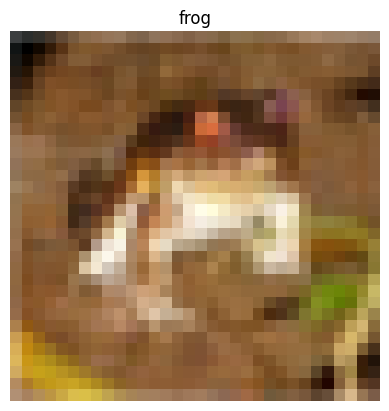

In [10]:
#Displaying image using matplotlib

plt.imshow(image.permute(1,2,0)) #rearranged dimensions to be height, width and channels where, 0,1,2 are indicies from the image.shape array e.g., [3,32,32] becomes (32,32,3)
plt.title(classes[label])
plt.axis("off")
plt.show()


**CREATING** **THE** **MODEL**

In [ ]:
import torch.nn as nn

class CNN(nn.Module): #Inheritance class
  def __init__(self):
    super().__init__() ##Inheriting attributes from parent class

#First convolutional layer
    self.conv1 = nn.Conv2d(
        in_channels=3, #Cause its an RGB
        out_channels=16,  #We're gonna ;earn 16 diff filters were one filter detects stuff like edges/vertical edges/corners etc
        kernel_size=3,
        padding=1
    )
